In [1]:
%%capture --no-stderr
%pip install --quiet -U langsmith langgraph google-genai langgraph-checkpoint-postgres psycopg psycopg-pool psycopg-binary langchain_community python-dotenv langchain-core==0.3.21

In [20]:
import os
import chainlit as cl
from google.genai import Client
from IPython.display import Image, display
from langchain.schema.runnable.config import RunnableConfig
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import MessagesState
from langgraph.checkpoint.memory import MemorySaver
from psycopg_pool import ConnectionPool
from langgraph.checkpoint.postgres import PostgresSaver

In [4]:
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
NEON_DB_URI = os.getenv("NEON_DB_URI")

os.environ["TAVILY_API_KEY"]= os.getenv("TAVILY_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "chatbot"

In [24]:
# Postgres DB

# Connection pool for efficient database access
connection_kwargs = {"autocommit": True, "prepare_threshold": 0}

# Create a persistent connection pool
pool = ConnectionPool(conninfo=NEON_DB_URI, max_size=50, kwargs=connection_kwargs)

# Initialize PostgresSaver checkpointer
checkpointer = PostgresSaver(pool)
checkpointer.setup()  # Ensure database tables are set up

memory = MemorySaver()

In [6]:
client = Client(
  http_options= {'api_version': 'v1alpha'}
)

MODEL: str = "gemini-2.0-flash-exp"

config = {
  "generation_config": {"response_modalities": ["TEXT"]}
  }

memory = MemorySaver()

# State
class State(MessagesState):
    pass

In [7]:
# User Preferences Agent
class UserPreferenceAgent:
    def __init__(self):
        self.user_data = {}

    def store_user_data(self, user_id: str, name: str = None):
        if user_id not in self.user_data:
            self.user_data[user_id] = {}
        if name:
            self.user_data[user_id]["name"] = name
        return f"Got it! I'll remember that your name is {name}."

    def retrieve_user_data(self, user_id: str):
        if user_id in self.user_data and "name" in self.user_data[user_id]:
            return f"Your name is {self.user_data[user_id]['name']}."
        else:
            return "I don't know your name yet."

user_pref_agent = UserPreferenceAgent()

In [8]:
# Invoke Messages

async def greet_user(state: State):
    # Ensure state contains 'messages'
    if "messages" not in state:
        raise ValueError("State must contain a 'messages' key.")
    
    # Extract the last user message from the state
    messages = state["messages"]
    last_message = messages[-1].content.lower()


    # Define a prompt to identify the greeting intent and respond dynamically
    intent_prompt = (
        f"The user said: '{last_message}'. "
        "If this is a greeting, respond with an appropriate greeting. "
        "If it's not a greeting, respond with: 'I only handle greetings right now.'"
    )

    # Call the LLM dynamically to get the response
    try:
        async with client.aio.live.connect(model=MODEL, config=config) as session:
            # Send the prompt to the LLM
            await session.send(input=intent_prompt, end_of_turn=True)
    
            # Stream the model's response
            response_text = ""
            turn = session.receive()  # session.receive() is an async generator, don't await here
            async for chunk in turn:  # Use async for to iterate over the generator
                if chunk.text is not None:
                    response_text += chunk.text

    except Exception as e:
        raise RuntimeError(f"Error invoking the model: {e}")

    # Append the LLM's response to the state messages
    response_message = AIMessage(content=response_text)
    messages.append(response_message)

    # Update and return the state
    return {"messages": messages[-1]}

In [9]:
# Conditional Check for User Preferences Flow
async def conditional_user_pref_flow(state: State):
    # Get the last user message
    last_message = state["messages"][-2].content.lower()

    # Check if the user wants to store their name
    if "my name is" in last_message:
        return "user_pref_store"  # Transition to store name node

    # Check if the user is asking for their name
    elif "what is my name" in last_message:
        return "user_pref_retrieve"  # Transition to retrieve name node

    # If the message doesn't match any condition, end the flow
    return END

# Store User Name
async def store_user_name(state: State):
    # Extract the last message and user_id from the state
    messages = state["messages"]
    last_message = messages[-1].content
    user_id = str(cl.context.session.id)  # Use the session ID as the user_id

    # Debug: Log the last message and user_id
    print(f"Last message: {last_message}")
    print(f"User ID: {user_id}")

    # Extract the name from the message (assuming the message follows the format "My name is ...")
    name = last_message.lower().replace("my name is", "").strip()

    # Debug: Log the extracted name
    print(f"Extracted name: {name}")

    if not name:
        response_message = "I couldn't understand your name. Please use the format 'My name is ...'."
    else:
        # Store the user's name using the UserPreferenceAgent
        response_message = user_pref_agent.store_user_data(user_id, name)

    # Append AI's response to state
    messages.append(AIMessage(content=response_message))
    return {"messages": messages}

In [10]:
# Node to retrieve user preferences
async def retrieve_user_name(state: State):
    # Extract user_id (for simplicity, assume it is stored with the session ID)
    user_id = str(cl.context.session.id)

    # Debug: Log the user_id
    print(f"User ID: {user_id}")

    # Retrieve the user's name using the UserPreferenceAgent
    response_message = user_pref_agent.retrieve_user_data(user_id)

    # Debug: Log the response message
    print(f"Response message: {response_message}")

    # Append AI's response to state
    messages = state["messages"]
    messages.append(AIMessage(content=response_message))  # Add AI's response to state
    return {"messages": messages}  # Return the updated state

In [25]:
# Build Graph

builder = StateGraph(State)

builder.add_node("greet", greet_user)
builder.add_node("user_pref_store", store_user_name)
builder.add_node("user_pref_retrieve", retrieve_user_name)

builder.add_edge(START, "greet")
builder.add_edge("user_pref_store", END)
builder.add_edge("user_pref_retrieve", END)
builder.add_conditional_edges(
    "greet",
    conditional_user_pref_flow,
    {"user_pref_store": "user_pref_store", "user_pref_retrieve": "user_pref_retrieve", END: END},
)

graph = builder.compile(checkpointer=memory)

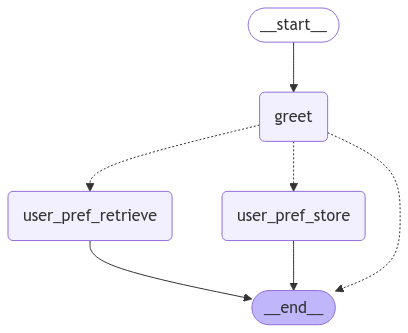

In [14]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
user_input = "hi"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="update"
)

for event in events:
    if "messages" in event:
        event.pretty_print()

2025-01-12 17:34:41 - b'{\n  "setupComplete": {}\n}\n'
